# M07: EDA - Multivariate Analysis
In this notebook, we explore interactions between multiple features simultaneously using correlation heatmaps and pairplots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.data import load_raw_data
from src.cleaning import clean_data

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (12, 8)})

df = clean_data(load_raw_data("../data/raw"))

# Encode Churn to numeric for correlation
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)


## 1. Correlation Heatmap (Numerical Features + Churn)
We compute the Pearson correlation between all numerical features and the binary-encoded churn target.

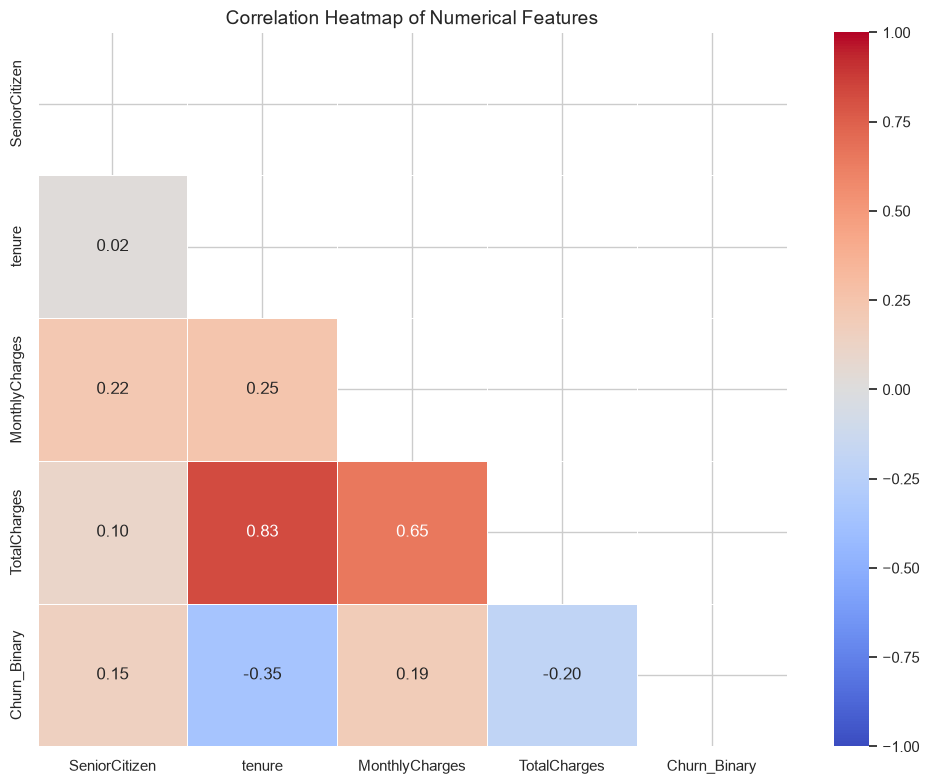

In [2]:
num_df = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']]

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation: Correlation Heatmap
- **tenure vs. Churn_Binary**: Moderate negative correlation (~-0.35). Longer-tenured customers are less likely to churn.
- **MonthlyCharges vs. Churn_Binary**: Weak positive correlation (~0.19). Higher monthly charges slightly increase churn risk.
- **TotalCharges vs. tenure**: Strong positive correlation (~0.83). Expected, since total charges accumulate over time.
- **TotalCharges vs. Churn_Binary**: Weak negative correlation. This is mostly a side-effect of the tenure relationship.
- **SeniorCitizen vs. Churn_Binary**: Very weak positive correlation. Being a senior citizen slightly increases churn tendency.

## 2. Pairplot of Key Numerical Features
A pairplot lets us see bivariate scatter distributions and marginal distributions simultaneously, colored by churn status.

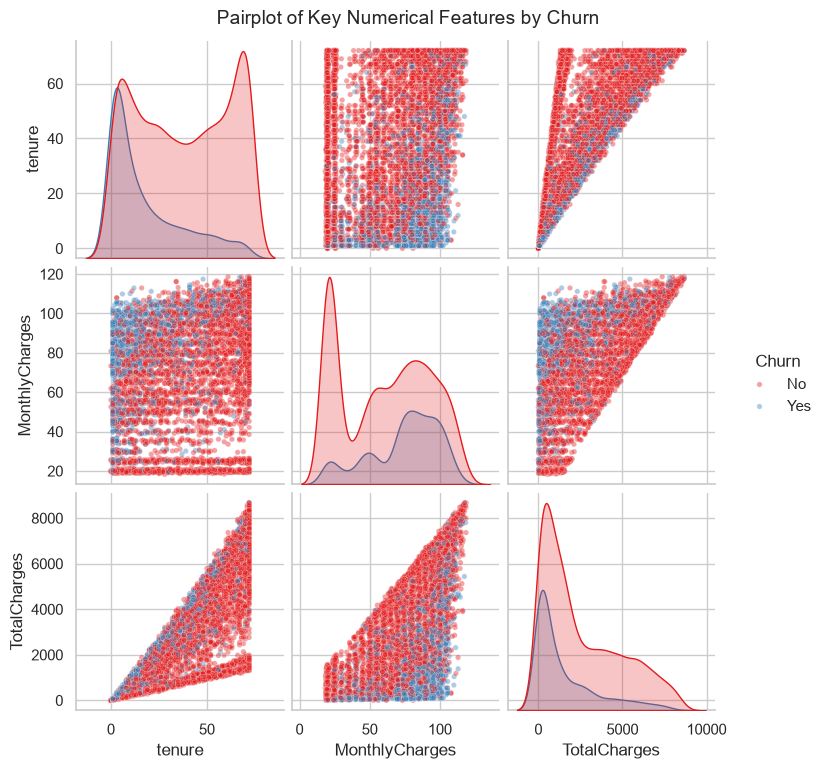

In [3]:
pair_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
sns.pairplot(df[pair_cols], hue='Churn', palette='Set1', diag_kind='kde', 
             plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairplot of Key Numerical Features by Churn', y=1.02, fontsize=14)
plt.show()

### Interpretation: Pairplot
- The scatter of **tenure vs. MonthlyCharges** reveals that churners (red) cluster heavily in the low-tenure / high-monthly-charges quadrant. This is the highest-risk segment.
- Non-churners spread across all tenure levels, but their density is highest at low monthly charges (basic plans) and high tenure (loyal customers).
- The diagonal KDE plots reinforce the univariate findings: churners have distinctly lower tenure and higher monthly charges.

## 3. Feature Interaction: Contract × MonthlyCharges × Churn
Let's look at how contract type interacts with monthly charges in predicting churn.

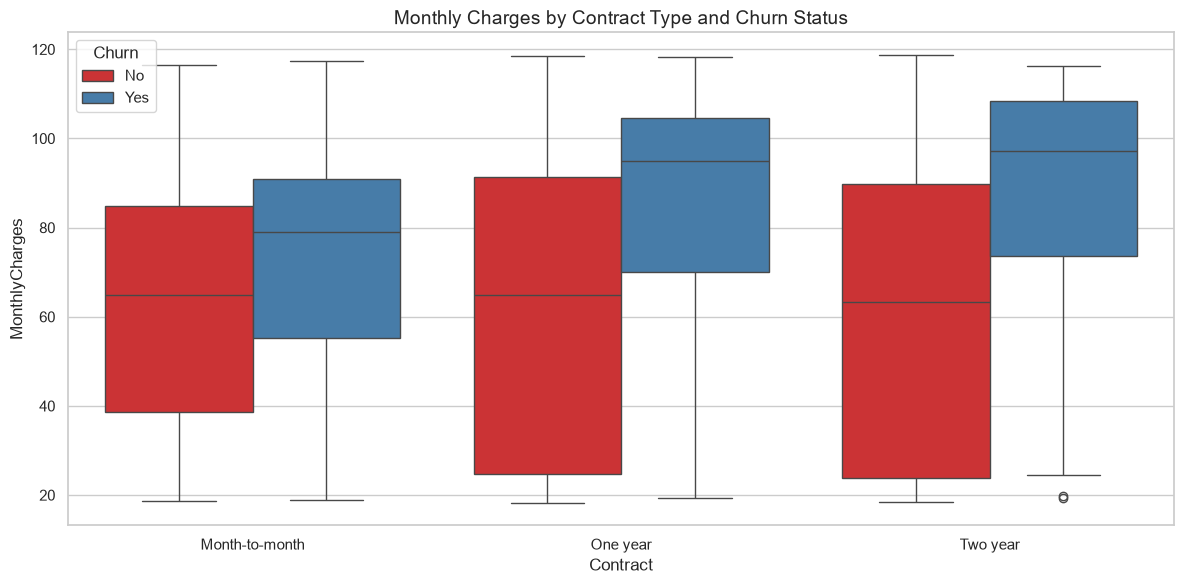

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn', palette='Set1', ax=ax)
ax.set_title('Monthly Charges by Contract Type and Churn Status', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation: Contract × MonthlyCharges
- Within **month-to-month** contracts, churners pay significantly higher monthly charges than non-churners. This suggests that month-to-month customers on expensive plans are the highest risk segment.
- For **one-year** and **two-year** contracts, the difference between churners and non-churners is much smaller, and overall churn rates are lower. Long-term contracts act as a strong retention mechanism regardless of pricing.